In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from datetime import datetime
from tqdm.notebook import tqdm

df = pd.read_csv("employee_churn.csv")
df.head(2)

,employee_id,age,gender,education_level,marital_status,tenure,job_role,department,salary,work_location,...,training_hours,promotions,overtime_hours,satisfaction_level,work_life_balance,average_monthly_hours_worked,absenteeism,distance_from_home,manager_feedback_score,churn
0,E00001,50,Male,Bachelor's,Married,5,Analyst,Marketing,93422,Remote,...,35,0,16,0.03,NaN,155,14,15,7.9,0
1,E00002,36,Male,Bachelor's,Married,4,Manager,Sales,44589,On-site,...,1,0,12,0.39,NaN,162,2,8,5.2,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   employee_id                   10000 non-null  object 
 1   age                           10000 non-null  int64  
 2   gender                        10000 non-null  object 
 3   education_level               10000 non-null  object 
 4   marital_status                10000 non-null  object 
 5   tenure                        10000 non-null  int64  
 6   job_role                      10000 non-null  object 
 7   department                    10000 non-null  object 
 8   salary                        10000 non-null  int64  
 9   work_location                 10000 non-null  object 
 10  performance_rating            10000 non-null  int64  
 11  projects_completed            10000 non-null  int64  
 12  training_hours                10000 non-null  int64  
 13  pr

In [26]:
df.drop(columns=['work_life_balance'],inplace=True)

In [27]:
df['churn'] = df['churn'].astype('bool')
df['tenure'] = df['tenure'].astype('int')
df['salary'] = df['salary'].astype('float')
df['performance_rating'] = df['performance_rating'].astype('float')
df['projects_completed'] = df['projects_completed'].astype('int')
df['training_hours'] = df['training_hours'].astype('int')
df['promotions'] = df['promotions'].astype('int')
df['overtime_hours'] = df['overtime_hours'].astype('int')
df['satisfaction_level'] = df['satisfaction_level'].astype('float')
df['average_monthly_hours_worked'] = df['average_monthly_hours_worked'].astype('int')
df['absenteeism'] = df['absenteeism'].astype('int')
df['distance_from_home'] = df['distance_from_home'].astype('float')
df['manager_feedback_score'] = df['manager_feedback_score'].astype('float')

In [28]:
df.nunique()

,0
employee_id,10000
age,38
gender,3
education_level,4
marital_status,3
tenure,15
job_role,4
department,4
salary,9566
work_location,3


In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df.isna().sum()

,0
employee_id,0
age,0
gender,0
education_level,0
marital_status,0
tenure,0
job_role,0
department,0
salary,0
work_location,0


**EDA**

In [31]:
df.columns

Index(['employee_id', 'age', 'gender', 'education_level', 'marital_status',
       'tenure', 'job_role', 'department', 'salary', 'work_location',
       'performance_rating', 'projects_completed', 'training_hours',
       'promotions', 'overtime_hours', 'satisfaction_level',
       'average_monthly_hours_worked', 'absenteeism', 'distance_from_home',
       'manager_feedback_score', 'churn'],
      dtype='object')

In [32]:
for col in ['education_level', 'marital_status', 'job_role', 'department', 'work_location','churn']:
    print(f'Unique values of {col}:',df[col].unique())
    print('-----')

Unique values of education_level: ["Bachelor's" 'High School' "Master's" 'PhD']
-----
Unique values of marital_status: ['Married' 'Single' 'Divorced']
-----
Unique values of job_role: ['Analyst' 'Manager' 'Sales' 'Developer']
-----
Unique values of department: ['Marketing' 'Sales' 'IT' 'HR']
-----
Unique values of work_location: ['Remote' 'On-site' 'Hybrid']
-----
Unique values of churn: [False  True]
-----


In [33]:
df.describe()

,age,tenure,salary,performance_rating,projects_completed,training_hours,promotions,overtime_hours,satisfaction_level,average_monthly_hours_worked,absenteeism,distance_from_home,manager_feedback_score
count,10000.000000,10000.000000,10000.0000,10000.0000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,40.561200,6.976800,89772.7548,3.0275,24.501200,49.715500,0.101000,24.2506,0.494940,224.53820,9.467700,24.491800,5.565430
std,10.876483,4.296988,34469.8058,1.4120,14.444461,28.930822,0.301344,14.4787,0.287771,43.62834,5.758635,14.512491,2.595523
min,22.000000,0.000000,30010.0000,1.0000,0.000000,0.000000,0.000000,0.0000,0.000000,150.00000,0.000000,0.000000,1.000000
25%,31.000000,3.000000,59718.5000,2.0000,12.000000,24.750000,0.000000,12.0000,0.247500,186.00000,4.000000,12.000000,3.300000
50%,41.000000,7.000000,89243.0000,3.0000,24.000000,49.000000,0.000000,24.0000,0.490000,225.00000,9.000000,24.000000,5.600000
75%,50.000000,11.000000,119725.5000,4.0000,37.000000,75.000000,0.000000,37.0000,0.740000,262.25000,14.000000,37.000000,7.800000
max,59.000000,14.000000,149993.0000,5.0000,49.000000,99.000000,1.000000,49.0000,1.000000,299.00000,19.000000,49.000000,10.000000


Setup style for **charts**

In [34]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [21]:
plt.style.use('ggplot')

**Correlation**

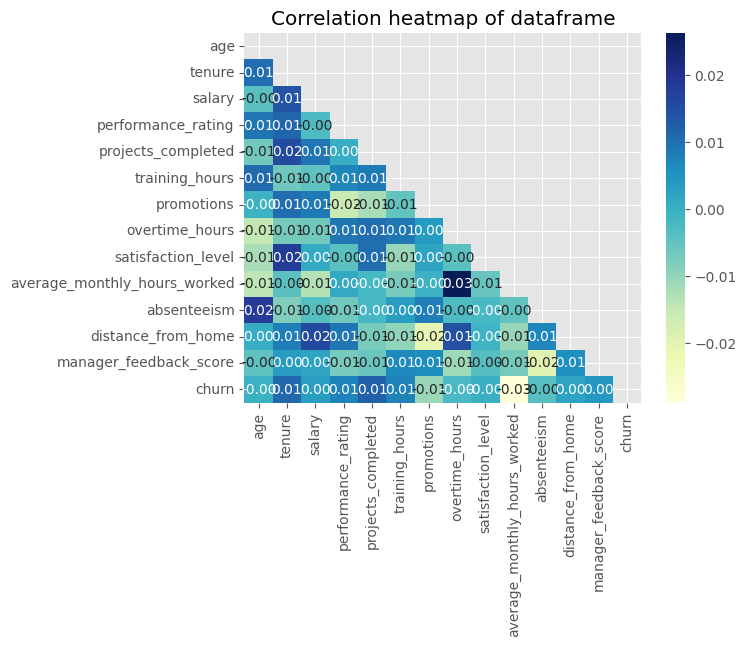

In [35]:
df_temp = df.copy()

sns.heatmap(df_temp.corr(numeric_only=True)
            ,annot=True
            ,cmap = 'YlGnBu'
            ,fmt = '.2f'
            ,mask = np.triu(df_temp.corr(numeric_only=True))
            )
plt.title('Correlation heatmap of dataframe')
plt.show()

                                   age    tenure    salary  \
age                           1.000000  0.010469 -0.003908   
tenure                        0.010469  1.000000  0.013858   
salary                       -0.003908  0.013858  1.000000   
performance_rating            0.009089  0.011512 -0.002632   
projects_completed           -0.006667  0.015609  0.009047   
training_hours                0.010782 -0.006382 -0.004688   
promotions                   -0.000452  0.010306  0.008799   
overtime_hours               -0.014848 -0.007208 -0.006753   
satisfaction_level           -0.012264  0.017914  0.001021   
average_monthly_hours_worked -0.014133 -0.004523 -0.013243   
absenteeism                   0.018084 -0.008283 -0.003620   
distance_from_home            0.000606  0.008001  0.015909   
manager_feedback_score       -0.004714  0.003547  0.002351   

                              performance_rating  projects_completed  \
age                                     0.009089           

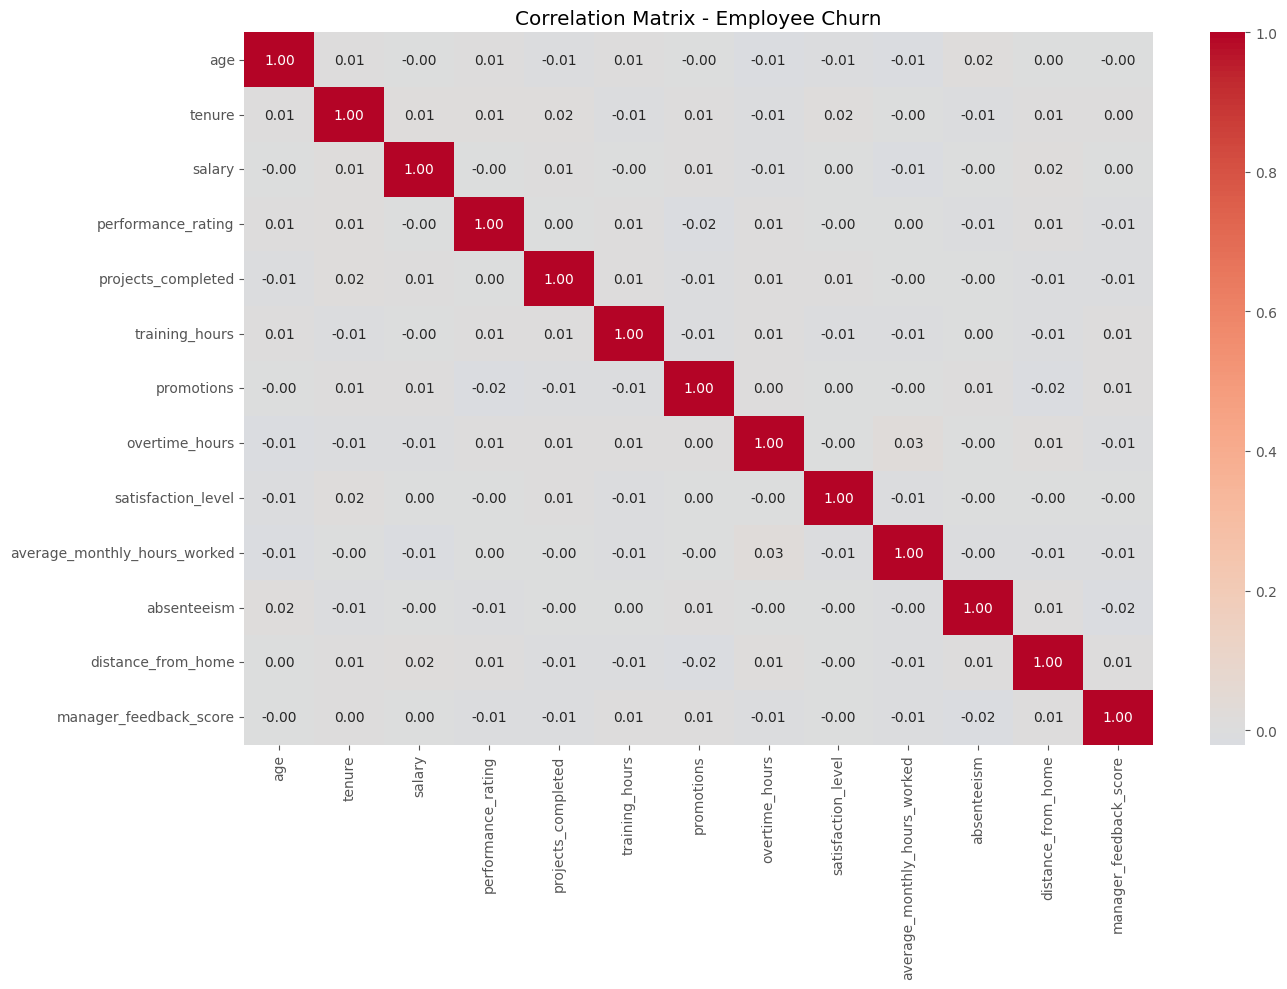

In [38]:
numeric_df = df.select_dtypes(include="number")

# Tính correlation
correlation = numeric_df.corr(method="pearson")

# Hiển thị correlation matrix
print(correlation)

# Vẽ heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix - Employee Churn")
plt.tight_layout()
plt.show()

In [42]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "gender",
        "education_level",
        "marital_status",
        "job_role",
        "department",
        "work_location"
    ],
    drop_first=True
)

df_encoded = df_encoded.drop(columns=['employee_id'])

correlation_encoded = df_encoded.corr()

churn_corr_encoded = (
    correlation_encoded["churn"]
    .drop("churn")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print(churn_corr_encoded.head(20))

average_monthly_hours_worked   -0.028854
gender_Other                   -0.027934
work_location_Remote           -0.015853
education_level_Master's        0.012567
projects_completed              0.012097
tenure                          0.011000
job_role_Sales                 -0.010825
promotions                     -0.010588
gender_Male                    -0.009214
work_location_On-site           0.008063
marital_status_Single           0.007831
training_hours                  0.007694
performance_rating              0.007439
job_role_Developer              0.007195
marital_status_Married         -0.006519
manager_feedback_score          0.004236
department_Marketing            0.003862
absenteeism                    -0.003693
salary                          0.003202
job_role_Manager                0.002439
Name: churn, dtype: float64


In [45]:
strong_corr = churn_corr_encoded[
    churn_corr_encoded.abs() > 0.01
].sort_values(
    key=abs,
    ascending=False
)

print("Variables with |Correlation| > 0.1:")
print(strong_corr)

Variables with |Correlation| > 0.1:
average_monthly_hours_worked   -0.028854
gender_Other                   -0.027934
work_location_Remote           -0.015853
education_level_Master's        0.012567
projects_completed              0.012097
tenure                          0.011000
job_role_Sales                 -0.010825
promotions                     -0.010588
Name: churn, dtype: float64


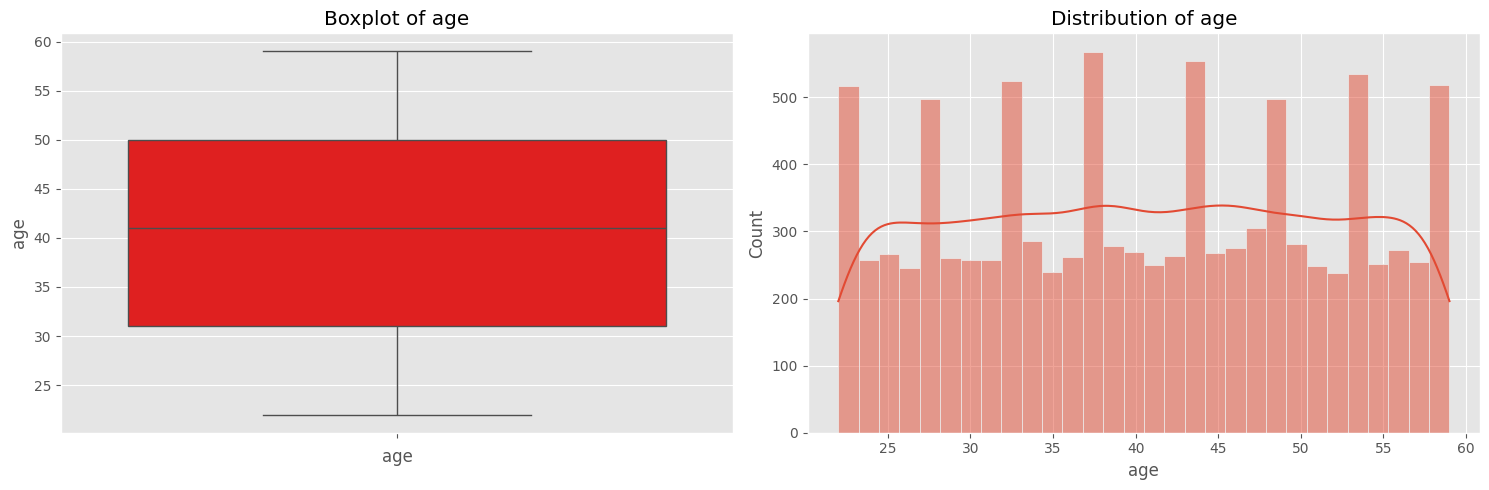

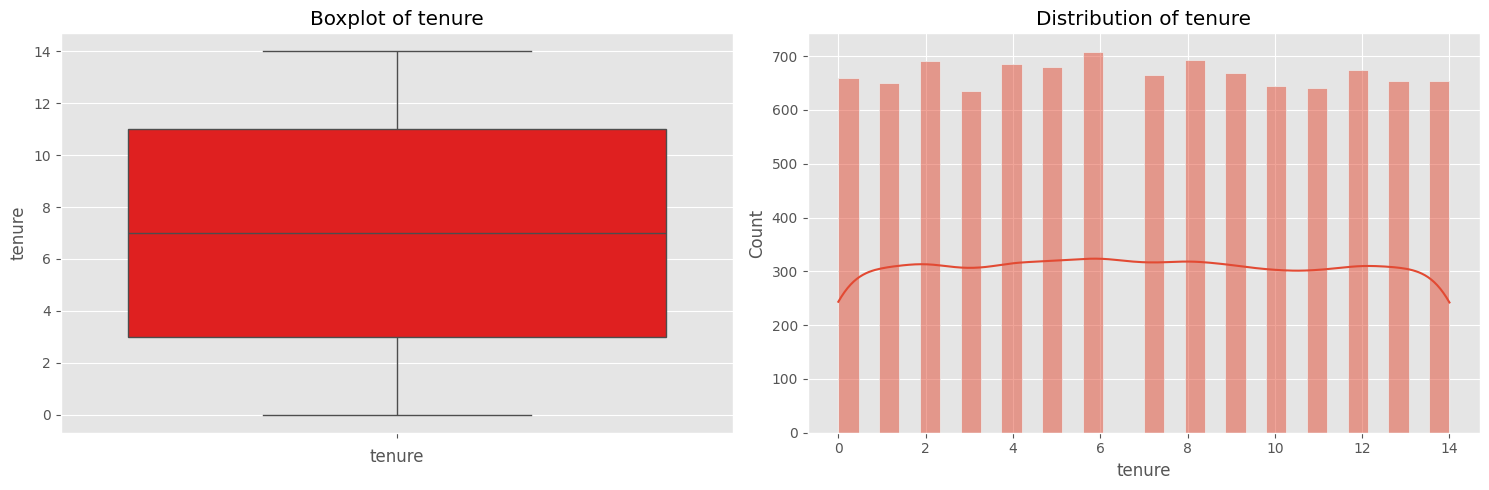

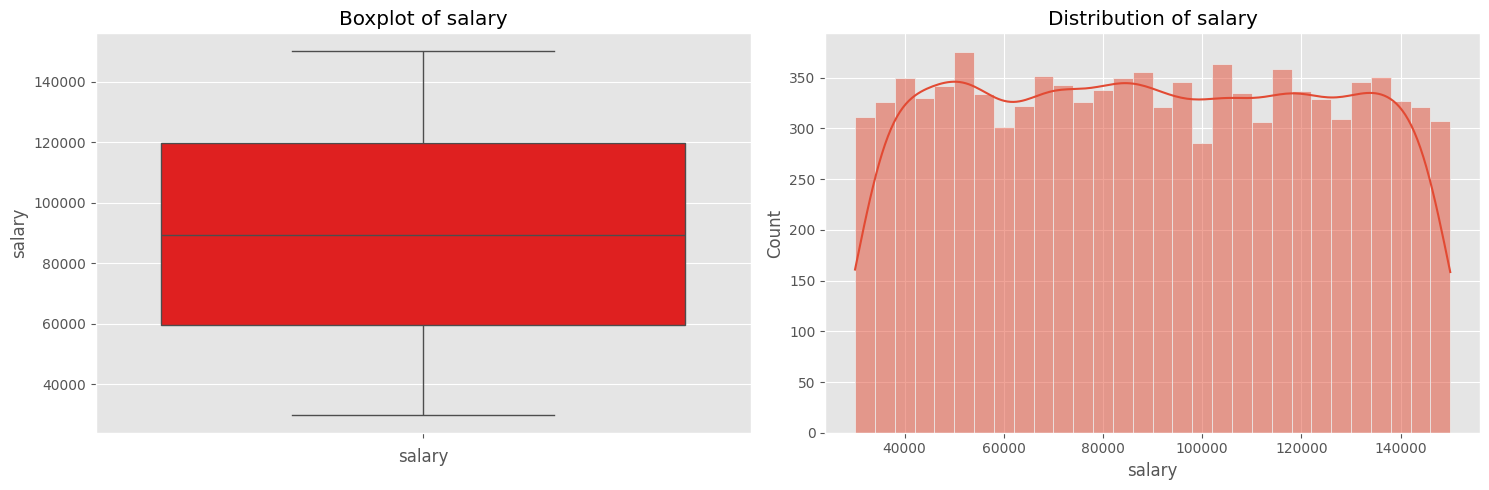

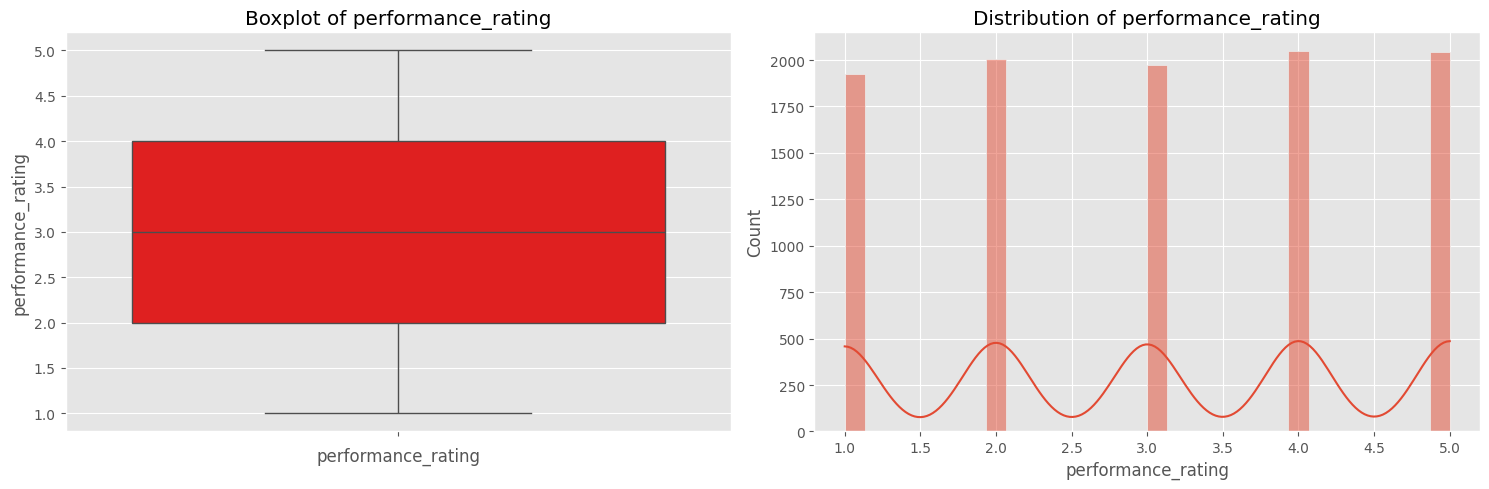

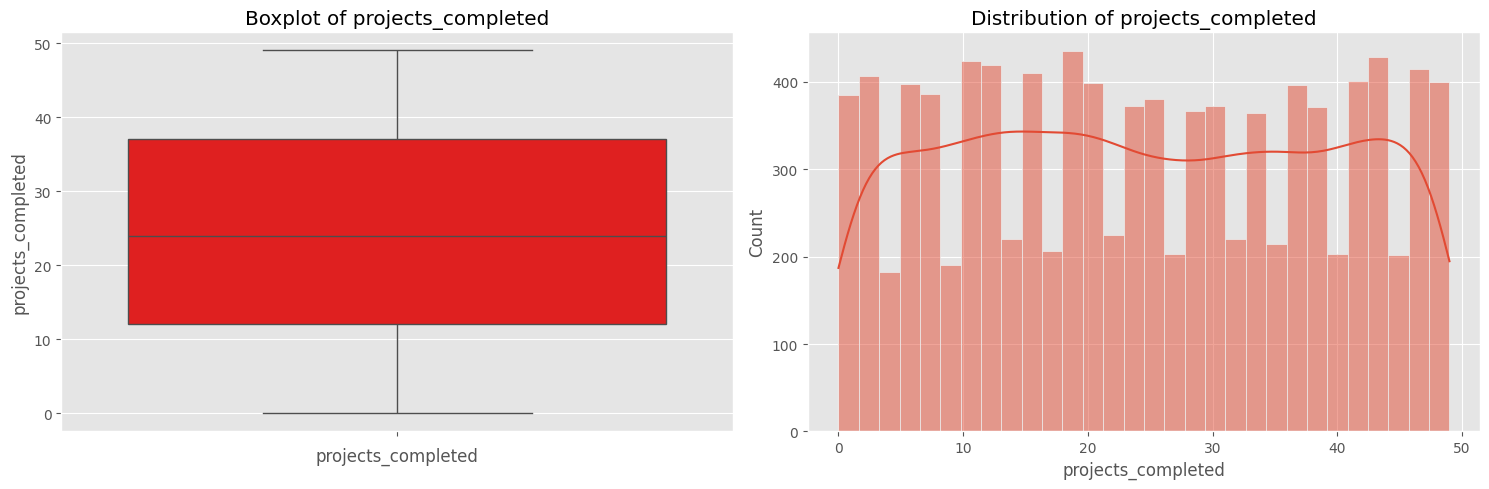

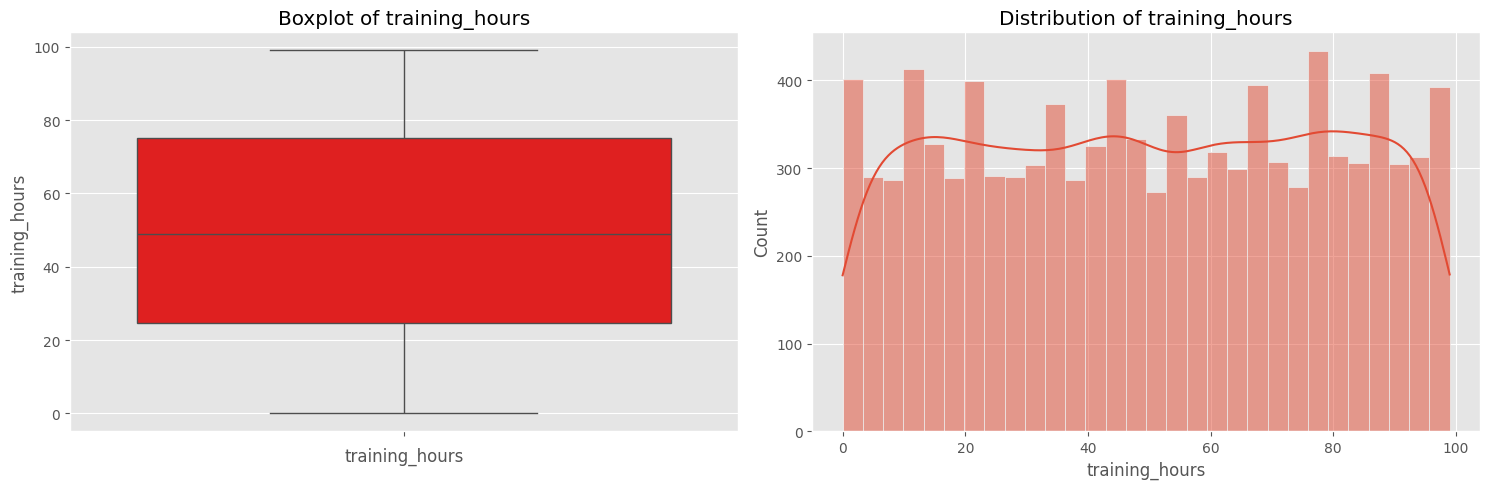

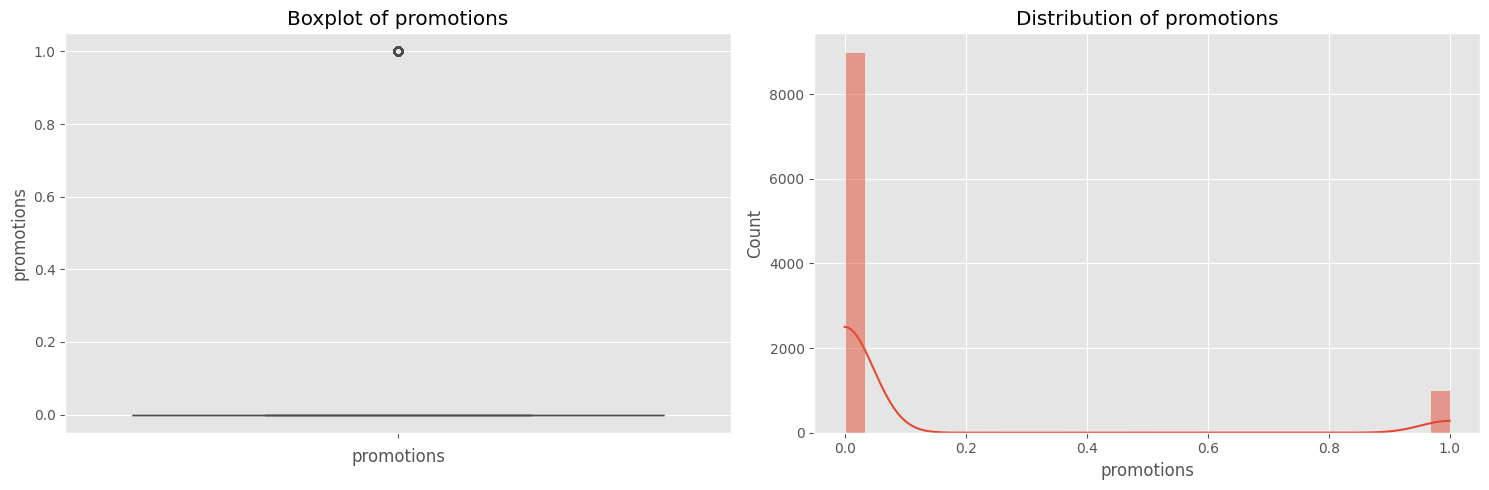

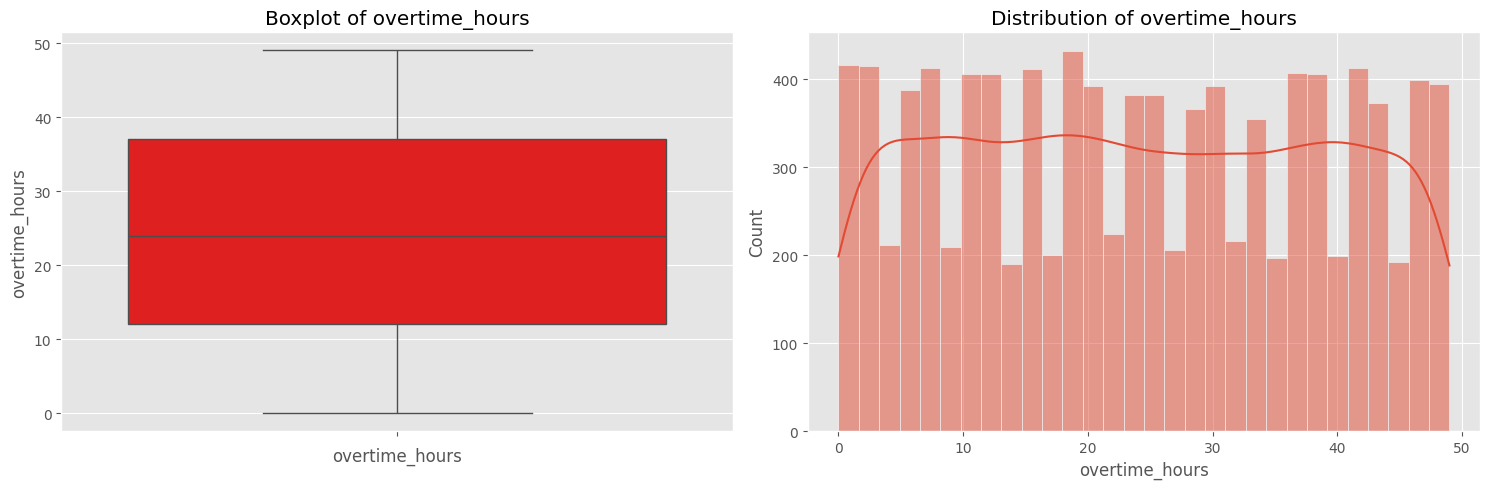

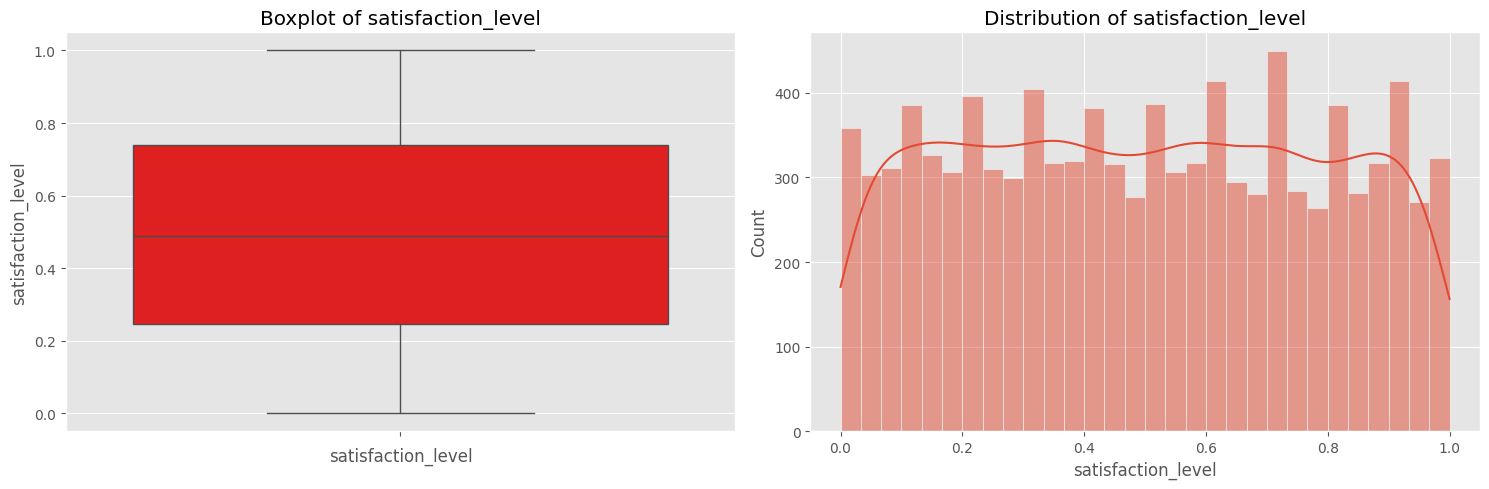

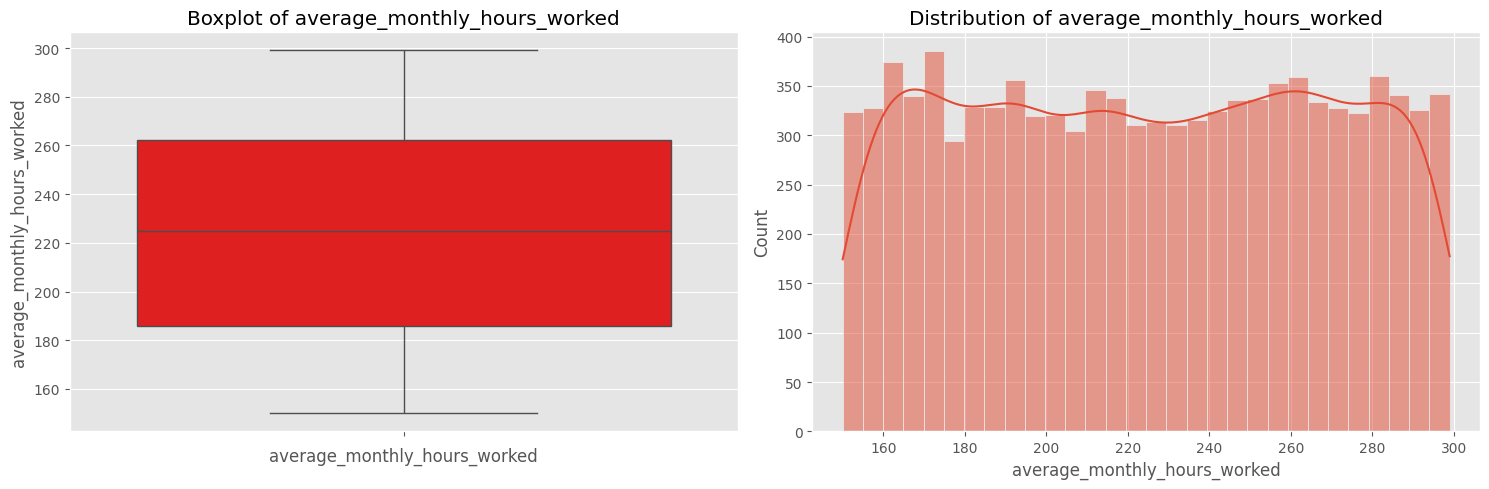

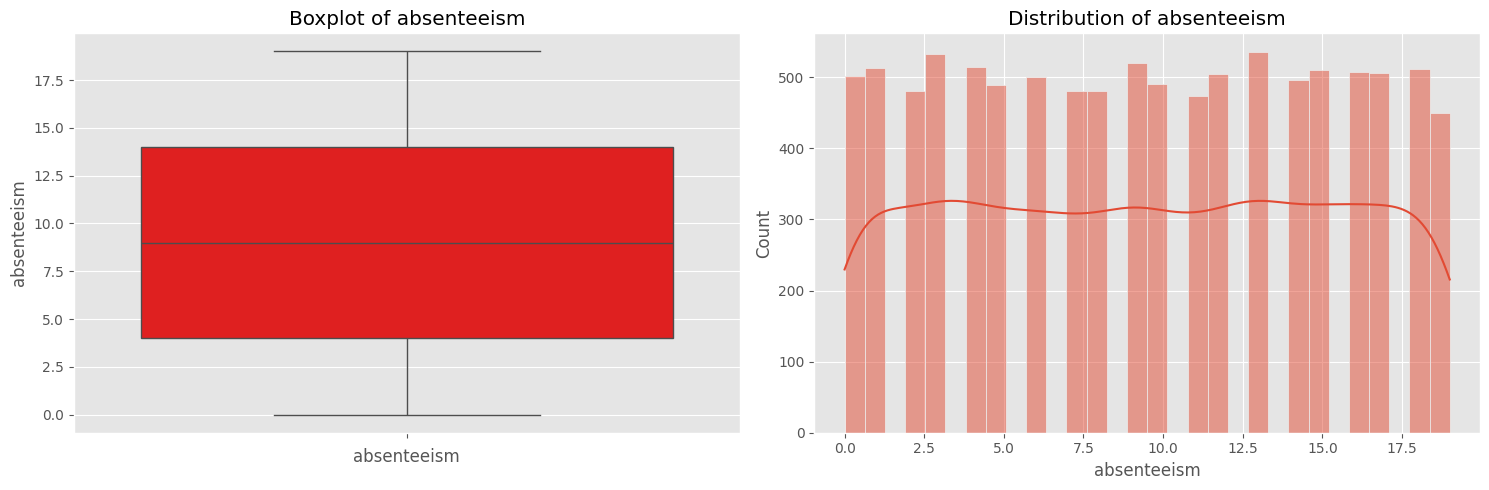

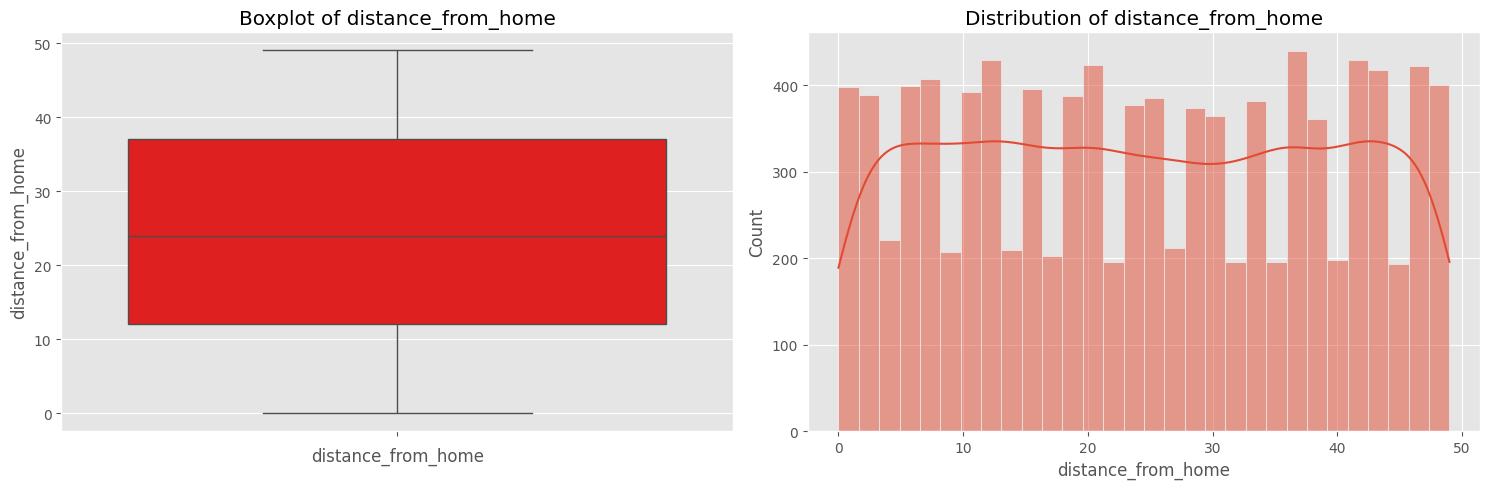

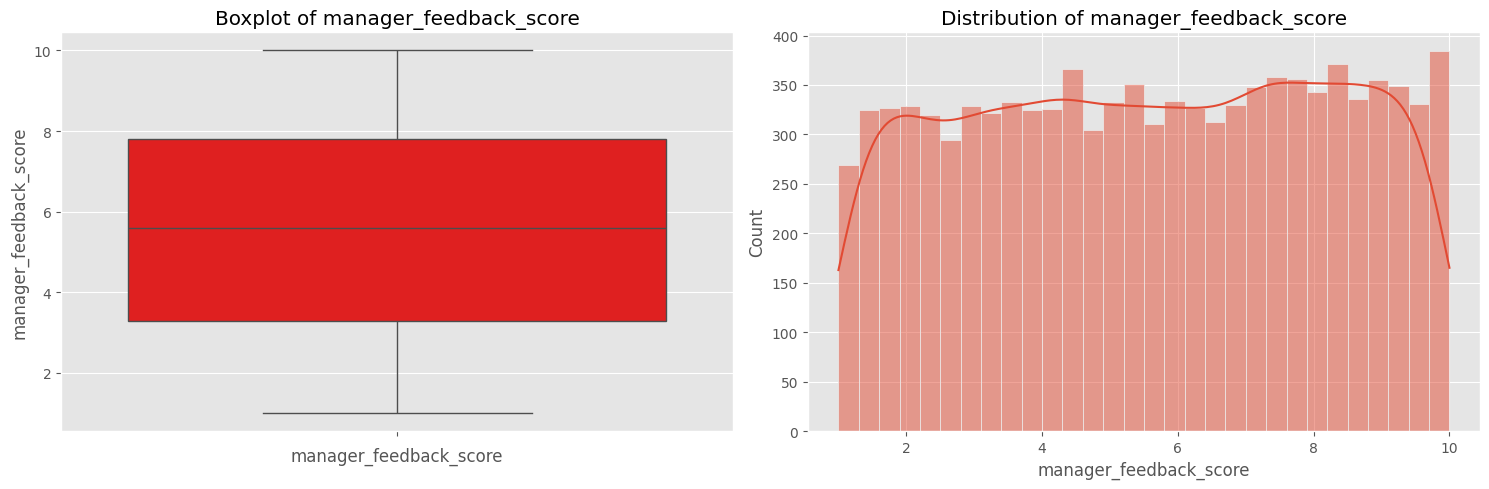

In [48]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        ax=axes[1]
    )
    axes[1].set_title(f"Distribution of {col}")
    axes[1].set_xlabel(col)

    sns.boxplot(
        df[col],
        color="red",
        ax=axes[0]
    )
    axes[0].set_title(f"Boxplot of {col}")
    axes[0].set_xlabel(col)

    plt.tight_layout()
    plt.show()

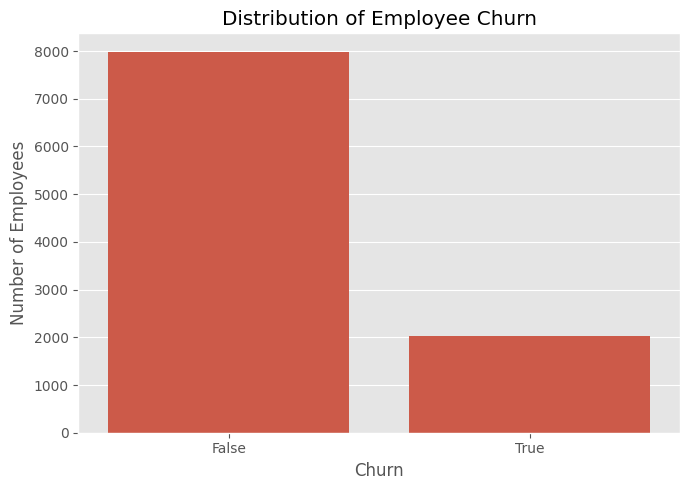

In [49]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="churn"
)

plt.title("Distribution of Employee Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

# **Yêu cầu ad-hoc**

Em cho chị tỷ lệ churn % tổng công ty - 1 con số. Chị cần để báo CEO trong họp all-hands sáng mai.


SELECT

  COUNT(*) AS total_employees,

  SUM(CAST(e.churn AS INT)) AS churned_employees,

  CAST(100.0 * SUM(CAST(e.churn AS INT)) / COUNT(*) AS DECIMAL(5, 2)) AS churn_rate_pct

FROM employees_churn AS e;

In [50]:
churn_percentage = (
    df["churn"]
    .value_counts(normalize=True)
    * 100
)

print(churn_percentage)

churn
False    79.72
True     20.28
Name: proportion, dtype: float64


Anh cần tỷ lệ churn theo từng department - department nào đang bị hemorrhage nhân sự?

SELECT
  e.department,

  COUNT(*) AS employees,

  SUM(CAST(e.churn AS INT)) AS churned,

  CAST(100.0 * SUM(CAST(e.churn AS INT)) / COUNT(*) AS DECIMAL(5, 2)) AS churn_rate_pct

FROM employees_churn AS e

GROUP BY e.department

ORDER BY churn_rate_pct DESC;

In [55]:
department_churn = df.groupby('department')['churn'].value_counts(normalize=True).unstack() * 100

department_churn_rate = department_churn[True].sort_values(ascending=False)

print("Tỷ lệ churn theo từng phòng ban:")
print(department_churn_rate)

Tỷ lệ churn theo từng phòng ban:
department
Marketing    20.748988
HR           20.250000
IT           20.231505
Sales        20.210665
Name: True, dtype: float64


Chị cần lương trung bình, min, max theo từng job role + số employee mỗi role. Để audit compensation.

SELECT

  e.job_role,

  COUNT(*) AS employees,

  CAST(AVG(e.salary) AS DECIMAL(14, 2)) AS avg_salary,

  CAST(MIN(e.salary) AS DECIMAL(14, 2)) AS min_salary,

  CAST(MAX(e.salary) AS DECIMAL(14, 2)) AS max_salary,

  CAST(MAX(e.salary)  MIN(e.salary) AS DECIMAL(14, 2)) AS salary_range

FROM employees_churn AS e

GROUP BY e.job_role

ORDER BY avg_salary DESC;

In [56]:
compensation_audit = df.groupby('job_role')['salary'].agg(['mean', 'min', 'max', 'size'])
compensation_audit = compensation_audit.rename(columns={'size': 'num_employees'})

print("Lương trung bình, min, max và số lượng nhân viên theo từng job role:")
print(compensation_audit)

Lương trung bình, min, max và số lượng nhân viên theo từng job role:
                   mean      min       max  num_employees
job_role                                                 
Analyst    89814.909334  30107.0  149993.0           2989
Developer  89506.681387  30029.0  149930.0           4008
Manager    89709.391691  30010.0  149955.0           2022
Sales      90861.992864  30122.0  149749.0            981


Em cho anh số employee theo (giới tính × trạng thái churn) - ma trận. Có khác biệt rõ giữa nam/nữ không?

SELECT

  e.gender,

  COUNT(*) AS employees,

  SUM(CASE WHEN e.churn = 1 THEN 1 ELSE 0 END) AS churned,

  SUM(CASE WHEN e.churn = 0 THEN 1 ELSE 0 END) AS stayed,

  CAST(100.0 * SUM(CAST(e.churn AS INT)) / COUNT(*) AS DECIMAL(5, 2)) AS churn_rate_pct
FROM employees_churn AS e

GROUP BY e.gender

ORDER BY e.gender;

In [57]:
gender_churn_analysis = df.groupby('gender').agg(
    employees=('employee_id', 'count'),
    churned=('churn', lambda x: (x == True).sum()),
    stayed=('churn', lambda x: (x == False).sum())
).reset_index()

gender_churn_analysis['churn_rate_pct'] = (gender_churn_analysis['churned'] / gender_churn_analysis['employees']) * 100

print("Phân tích tỷ lệ churn theo giới tính:")
print(gender_churn_analysis)

Phân tích tỷ lệ churn theo giới tính:
   gender  employees  churned  stayed  churn_rate_pct
0  Female       4826     1013    3813       20.990468
1    Male       4973      990    3983       19.907501
2   Other        201       25     176       12.437811


Chị cần tỷ lệ churn theo các nhóm tenure: dưới 1 năm, 1-3 năm, 3-5 năm, trên 5 năm. Nhóm nào dễ rời nhất?

SELECT

  CASE

    WHEN e.tenure < 1 THEN '1. Dưới 1 năm'

    WHEN e.tenure < 3 THEN '2. 1-3 năm'

    WHEN e.tenure < 5 THEN '3. 3-5 năm'

    ELSE '4. Trên 5 năm'

  END AS tenure_band,

  COUNT(*) AS employees,

  SUM(CAST(e.churn AS INT)) AS churned,

  CAST(100.0 * SUM(CAST(e.churn AS INT)) / COUNT(*) AS DECIMAL(5, 2)) AS churn_rate_pct
FROM employees_churn AS e

GROUP BY

  CASE

    WHEN e.tenure < 1 THEN '1. Dưới 1 năm'

    WHEN e.tenure < 3 THEN '2. 1-3 năm'

    WHEN e.tenure < 5 THEN '3. 3-5 năm'

    ELSE '4. Trên 5 năm'

  END

ORDER BY tenure_band;

In [58]:
def create_tenure_band(tenure):
    if tenure < 1:
        return '1. Dưới 1 năm'
    elif tenure < 3:
        return '2. 1-3 năm'
    elif tenure < 5:
        return '3. 3-5 năm'
    else:
        return '4. Trên 5 năm'

df['tenure_band'] = df['tenure'].apply(create_tenure_band)

tenure_churn_analysis = df.groupby('tenure_band').agg(
    employees=('employee_id', 'count'),
    churned=('churn', lambda x: (x == True).sum()),
    stayed=('churn', lambda x: (x == False).sum())
).reset_index()

tenure_churn_analysis['churn_rate_pct'] = (tenure_churn_analysis['churned'] / tenure_churn_analysis['employees']) * 100

print("Phân tích tỷ lệ churn theo nhóm thâm niên:")
print(tenure_churn_analysis.sort_values(by='tenure_band'))

Phân tích tỷ lệ churn theo nhóm thâm niên:
     tenure_band  employees  churned  stayed  churn_rate_pct
0  1. Dưới 1 năm        660      124     536       18.787879
1     2. 1-3 năm       1340      248    1092       18.507463
2     3. 3-5 năm       1321      273    1048       20.666162
3  4. Trên 5 năm       6679     1383    5296       20.706693


Anh nghi lương không reflect performance. Em check: chia performance rating thành 3 nhóm (1-2, 3, 4-5), tính lương trung bình mỗi nhóm. Rating cao có lương cao hơn không?

SELECT

  CASE

    WHEN e.performance_rating <= 2 THEN '1. Thấp (1-2)'

    WHEN e.performance_rating = 3 THEN '2. Trung bình (3)'

    ELSE '3. Cao (4-5)'

  END AS performance_band,

  COUNT(*) AS employees,

  CAST(AVG(e.salary) AS DECIMAL(14, 2)) AS avg_salary,

  CAST(MIN(e.salary) AS DECIMAL(14, 2)) AS min_salary,

  CAST(MAX(e.salary) AS DECIMAL(14, 2)) AS max_salary,

  CAST(100.0 * SUM(CAST(e.churn AS INT)) / COUNT(*) AS DECIMAL(5, 2)) AS churn_rate_pct

FROM employees_churn AS e

GROUP BY

  CASE

    WHEN e.performance_rating <= 2 THEN '1. Thấp (1-2)'

    WHEN e.performance_rating = 3 THEN '2. Trung bình (3)'

    ELSE '3. Cao (4-5)'

  END

ORDER BY performance_band;

In [59]:
def create_performance_band(rating):
    if rating <= 2:
        return '1. Thấp (1-2)'
    elif rating == 3:
        return '2. Trung bình (3)'
    else:
        return '3. Cao (4-5)'

df['performance_band'] = df['performance_rating'].apply(create_performance_band)

performance_salary_analysis = df.groupby('performance_band').agg(
    employees=('employee_id', 'count'),
    avg_salary=('salary', 'mean'),
    min_salary=('salary', 'min'),
    max_salary=('salary', 'max'),
    churned=('churn', lambda x: (x == True).sum())
).reset_index()

performance_salary_analysis['churn_rate_pct'] = (performance_salary_analysis['churned'] / performance_salary_analysis['employees']) * 100

print("Phân tích lương và tỷ lệ churn theo nhóm đánh giá hiệu suất:")
print(performance_salary_analysis.sort_values(by='performance_band'))

Phân tích lương và tỷ lệ churn theo nhóm đánh giá hiệu suất:
    performance_band  employees    avg_salary  min_salary  max_salary  \
0      1. Thấp (1-2)       3935  89948.782973     30029.0    149993.0   
1  2. Trung bình (3)       1973  89268.744045     30040.0    149912.0   
2       3. Cao (4-5)       4092  89846.494379     30010.0    149926.0   

   churned  churn_rate_pct  
0      782       19.872935  
1      423       21.439432  
2      823       20.112414  


Chị muốn biết overtime có gây churn không: chia employee theo nhóm overtime (0, 1-10, 10-20, trên 20 giờ/tháng), tính churn rate mỗi nhóm.

SELECT

  CASE

    WHEN e.overtime_hours = 0 THEN '1. Không OT'

    WHEN e.overtime_hours <= 10 THEN '2. 1-10 giờ'

    WHEN e.overtime_hours <= 20 THEN '3. 11-20 giờ'

    ELSE '4. Trên 20 giờ'

  END AS overtime_band,

  COUNT(*) AS employees,

  SUM(CAST(e.churn AS INT)) AS churned,

  CAST(100.0 * SUM(CAST(e.churn AS INT)) / COUNT(*) AS DECIMAL(5, 2)) AS churn_rate_pct,

  CAST(AVG(e.satisfaction_level) AS DECIMAL(6, 4)) AS avg_satisfaction

FROM employees_churn AS e

GROUP BY

  CASE

    WHEN e.overtime_hours = 0 THEN '1. Không OT'

    WHEN e.overtime_hours <= 10 THEN '2. 1-10 giờ'

    WHEN e.overtime_hours <= 20 THEN '3. 11-20 giờ'

    ELSE '4. Trên 20 giờ'

  END

ORDER BY overtime_band;

In [60]:
def create_overtime_band(hours):
    if hours == 0:
        return '1. Không OT'
    elif hours <= 10:
        return '2. 1-10 giờ'
    elif hours <= 20:
        return '3. 11-20 giờ'
    else:
        return '4. Trên 20 giờ'

df['overtime_band'] = df['overtime_hours'].apply(create_overtime_band)

overtime_analysis = df.groupby('overtime_band').agg(
    employees=('employee_id', 'count'),
    churned=('churn', lambda x: (x == True).sum()),
    avg_satisfaction=('satisfaction_level', 'mean')
).reset_index()

overtime_analysis['churn_rate_pct'] = (overtime_analysis['churned'] / overtime_analysis['employees']) * 100

print("Phân tích tỷ lệ churn và mức độ hài lòng theo nhóm giờ làm thêm:")
print(overtime_analysis.sort_values(by='overtime_band'))

Phân tích tỷ lệ churn và mức độ hài lòng theo nhóm giờ làm thêm:
    overtime_band  employees  churned  avg_satisfaction  churn_rate_pct
0     1. Không OT        216       54          0.490648       25.000000
1     2. 1-10 giờ       2068      406          0.495779       19.632495
2    3. 11-20 giờ       2019      416          0.502576       20.604260
3  4. Trên 20 giờ       5697     1152          0.492092       20.221169


Anh cần ma trận 2D số giờ làm trung bình mỗi tháng × mức độ hài lòng × tỷ lệ churn. Để thấy tổ hợp nào tệ nhất.

SELECT

  CASE

    WHEN e.average_monthly_hours_worked < 180 THEN '1. Dưới 180 giờ'

    WHEN e.average_monthly_hours_worked < 220 THEN '2. 180-219 giờ'

    WHEN e.average_monthly_hours_worked < 260 THEN '3. 220-259 giờ'

    ELSE '4. Từ 260 giờ'

  END AS workload_band,

  CASE

    WHEN e.satisfaction_level < 0.34 THEN '1. Thấp'

    WHEN e.satisfaction_level < 0.67 THEN '2. Trung bình'

    ELSE '3. Cao'

  END AS satisfaction_band,

  COUNT(*) AS employees,

  CAST(100.0 * SUM(CAST(e.churn AS INT)) / COUNT(*) AS DECIMAL(5, 2)) AS
  churn_rate_pct

FROM employees_churn AS e

GROUP BY

  CASE

    WHEN e.average_monthly_hours_worked < 180 THEN '1. Dưới 180 giờ'

    WHEN e.average_monthly_hours_worked < 220 THEN '2. 180-219 giờ'

    WHEN e.average_monthly_hours_worked < 260 THEN '3. 220-259 giờ'

    ELSE '4. Từ 260 giờ'

  END,

  CASE

    WHEN e.satisfaction_level < 0.34 THEN '1. Thấp'

    WHEN e.satisfaction_level < 0.67 THEN '2. Trung bình'

    ELSE '3. Cao'

  END

ORDER BY workload_band, satisfaction_band;

In [61]:
def create_workload_band(hours):
    if hours < 180:
        return '1. Dưới 180 giờ'
    elif hours < 220:
        return '2. 180-219 giờ'
    elif hours < 260:
        return '3. 220-259 giờ'
    else:
        return '4. Từ 260 giờ'

def create_satisfaction_band(level):
    if level < 0.34:
        return '1. Thấp'
    elif level < 0.67:
        return '2. Trung bình'
    else:
        return '3. Cao'

df['workload_band'] = df['average_monthly_hours_worked'].apply(create_workload_band)
df['satisfaction_band'] = df['satisfaction_level'].apply(create_satisfaction_band)

workload_satisfaction_churn = df.groupby(['workload_band', 'satisfaction_band']).agg(
    employees=('employee_id', 'count'),
    churned=('churn', lambda x: (x == True).sum())
).reset_index()

workload_satisfaction_churn['churn_rate_pct'] = (workload_satisfaction_churn['churned'] / workload_satisfaction_churn['employees']) * 100

print("Ma trận 2D: Giờ làm trung bình mỗi tháng × Mức độ hài lòng × Tỷ lệ Churn:")
print(workload_satisfaction_churn.sort_values(by=['workload_band', 'satisfaction_band']))

Ma trận 2D: Giờ làm trung bình mỗi tháng × Mức độ hài lòng × Tỷ lệ Churn:
      workload_band satisfaction_band  employees  churned  churn_rate_pct
0   1. Dưới 180 giờ           1. Thấp        707      156       22.065064
1   1. Dưới 180 giờ     2. Trung bình        662      134       20.241692
2   1. Dưới 180 giờ            3. Cao        676      147       21.745562
3    2. 180-219 giờ           1. Thấp        902      197       21.840355
4    2. 180-219 giờ     2. Trung bình        886      194       21.896163
5    2. 180-219 giờ            3. Cao        855      182       21.286550
6    3. 220-259 giờ           1. Thấp        863      186       21.552723
7    3. 220-259 giờ     2. Trung bình        885      160       18.079096
8    3. 220-259 giờ            3. Cao        851      174       20.446533
9     4. Từ 260 giờ           1. Thấp        927      167       18.015102
10    4. Từ 260 giờ     2. Trung bình        898      165       18.374165
11    4. Từ 260 giờ            3. Cao 

Chị cần top 10 department có absenteeism cao nhất + số employee. Để team Ops follow up.

SELECT TOP (10)

  e.department,

  COUNT(*) AS employees,

  CAST(AVG(CAST(e.absenteeism AS DECIMAL(10, 4))) AS DECIMAL(8, 2)) AS avg_absenteeism_days,

  MAX(e.absenteeism) AS max_absenteeism_days,

  CAST(100.0 * SUM(CAST(e.churn AS INT)) / COUNT(*) AS DECIMAL(5, 2)) AS churn_rate_pct

FROM employees_churn AS e

GROUP BY e.department

ORDER BY avg_absenteeism_days DESC;

In [63]:
top_absenteeism_departments = df.groupby('department').agg(
    employees=('employee_id', 'count'),
    avg_absenteeism_days=('absenteeism', 'mean'),
    max_absenteeism_days=('absenteeism', 'max'),
    churned=('churn', lambda x: (x == True).sum())
).reset_index()

top_absenteeism_departments['churn_rate_pct'] = (top_absenteeism_departments['churned'] / top_absenteeism_departments['employees']) * 100

top_10_absenteeism = top_absenteeism_departments.sort_values(by='avg_absenteeism_days', ascending=False).head(10)

print("Top 10 phòng ban có số ngày vắng mặt trung bình cao nhất:")
print(top_10_absenteeism)

Top 10 phòng ban có số ngày vắng mặt trung bình cao nhất:
  department  employees  avg_absenteeism_days  max_absenteeism_days  churned  \
3      Sales       3038              9.503292                    19      614   
0         HR       2000              9.454000                    19      405   
1         IT       3974              9.453951                    19      804   
2  Marketing        988              9.441296                    19      205   

   churn_rate_pct  
3       20.210665  
0       20.250000  
1       20.231505  
2       20.748988  


Anh cần check fairness: chia feedback score thành low/mid/high, tính số lần promotion trung bình + churn rate mỗi nhóm. Manager đánh giá cao có dẫn đến promotion không?

SELECT

  CASE

    WHEN e.manager_feedback_score <= 4 THEN '1. Thấp (1-4)'

    WHEN e.manager_feedback_score <= 7 THEN '2. Trung bình (5-7)'

    ELSE '3. Cao (8-10)'

  END AS feedback_band,

  COUNT(*) AS employees,

  CAST(AVG(CAST(e.promotions AS DECIMAL(10, 4))) AS DECIMAL(6, 4)) AS avg_promotions,

  CAST(100.0 * SUM(CAST(e.churn AS INT)) / COUNT(*) AS DECIMAL(5, 2)) AS churn_rate_pct,

  CAST(AVG(e.salary) AS DECIMAL(14, 2)) AS avg_salary

FROM employees_churn AS e

GROUP BY

  CASE

    WHEN e.manager_feedback_score <= 4 THEN '1. Thấp (1-4)'

    WHEN e.manager_feedback_score <= 7 THEN '2. Trung bình (5-7)'

    ELSE '3. Cao (8-10)'

  END

ORDER BY feedback_band;

In [64]:
def create_feedback_band(score):
    if score <= 4:
        return '1. Thấp (1-4)'
    elif score <= 7:
        return '2. Trung bình (5-7)'
    else:
        return '3. Cao (8-10)'

df['feedback_band'] = df['manager_feedback_score'].apply(create_feedback_band)

feedback_analysis = df.groupby('feedback_band').agg(
    employees=('employee_id', 'count'),
    avg_promotions=('promotions', 'mean'),
    churned=('churn', lambda x: (x == True).sum()),
    avg_salary=('salary', 'mean')
).reset_index()

feedback_analysis['churn_rate_pct'] = (feedback_analysis['churned'] / feedback_analysis['employees']) * 100

print("Phân tích sự công bằng theo điểm phản hồi của quản lý:")
print(feedback_analysis.sort_values(by='feedback_band'))

Phân tích sự công bằng theo điểm phản hồi của quản lý:
         feedback_band  employees  avg_promotions  churned    avg_salary  \
0        1. Thấp (1-4)       3276        0.101648      657  89766.460317   
1  2. Trung bình (5-7)       3304        0.096852      679  89761.881659   
2        3. Cao (8-10)       3420        0.104386      692  89789.288596   

   churn_rate_pct  
0       20.054945  
1       20.550847  
2       20.233918  


Chị cần list employee có lương thấp hơn 25% peer cùng role - potential flight risk. Team comp team cần review.

WITH role_stats AS (

  SELECT

    job_role,

    AVG(salary) AS role_avg_salary

  FROM employees_churn

  GROUP BY job_role

)

SELECT

  e.employee_id,

  e.job_role,

  e.department,

  CAST(e.salary AS DECIMAL(14, 2)) AS salary,

  CAST(r.role_avg_salary AS DECIMAL(14, 2)) AS role_avg_salary,

  CAST(100.0 * (e.salary - r.role_avg_salary) / r.role_avg_salary AS DECIMAL
  (6, 2)) AS gap_pct,
  e.performance_rating,

  e.churn

FROM employees_churn AS e

JOIN role_stats AS r

  ON r.job_role = e.job_role

WHERE e.salary < r.role_avg_salary * 0.75

ORDER BY gap_pct, e.employee_id;

In [65]:
role_avg_salary = df.groupby('job_role')['salary'].mean().reset_index()
role_avg_salary = role_avg_salary.rename(columns={'salary': 'role_avg_salary'})

merged_df = pd.merge(df, role_avg_salary, on='job_role', how='left')

flight_risk_employees = merged_df[merged_df['salary'] < (merged_df['role_avg_salary'] * 0.75)]

flight_risk_employees['gap_pct'] = ((flight_risk_employees['salary'] - flight_risk_employees['role_avg_salary']) / flight_risk_employees['role_avg_salary']) * 100

flight_risk_employees = flight_risk_employees[[
    'employee_id',
    'job_role',
    'department',
    'salary',
    'role_avg_salary',
    'gap_pct',
    'performance_rating',
    'churn'
]].sort_values(by='gap_pct', ascending=True)

print("Danh sách nhân viên có lương thấp hơn 25% so với đồng nghiệp cùng role (potential flight risk):")
display(flight_risk_employees)

Danh sách nhân viên có lương thấp hơn 25% so với đồng nghiệp cùng role (potential flight risk):


/tmp/ipykernel_1455/556355125.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flight_risk_employees['gap_pct'] = ((flight_risk_employees['salary'] - flight_risk_employees['role_avg_salary']) / flight_risk_employees['role_avg_salary']) * 100


,employee_id,job_role,department,salary,role_avg_salary,gap_pct,performance_rating,churn
7840,E07841,Sales,HR,30122.0,90861.992864,-66.848625,4.0,False
8859,E08860,Sales,Sales,30203.0,90861.992864,-66.759479,3.0,True
9047,E09048,Sales,Marketing,30212.0,90861.992864,-66.749574,2.0,False
1318,E01319,Sales,IT,30281.0,90861.992864,-66.673634,5.0,False
7735,E07736,Sales,IT,30310.0,90861.992864,-66.641718,1.0,False
...,...,...,...,...,...,...,...,...
1014,E01015,Manager,IT,67207.0,89709.391691,-25.083652,4.0,False
3819,E03820,Analyst,IT,67290.0,89814.909334,-25.079254,4.0,False
3274,E03275,Developer,Sales,67065.0,89506.681387,-25.072633,1.0,False
7654,E07655,Developer,IT,67102.0,89506.681387,-25.031295,2.0,True


Anh cần churn rate theo 10 decile tenure - tuổi nghề nào là sweet spot stay, giai đoạn nào churn mạnh?

WITH deciles AS (

  SELECT

    employee_id,

    tenure,

    churn,

    NTILE(10) OVER (ORDER BY tenure, employee_id) AS tenure_decile

  FROM employees_churn

)

SELECT

  tenure_decile,

  MIN(tenure) AS min_tenure,

  MAX(tenure) AS max_tenure,

  COUNT(*) AS employees,

  SUM(CAST(churn AS INT)) AS churned,

  CAST(100.0 * SUM(CAST(churn AS INT)) / COUNT(*) AS DECIMAL(5, 2)) AS churn_rate_pct

FROM deciles

GROUP BY tenure_decile

ORDER BY tenure_decile;

In [67]:
# Sắp xếp DataFrame theo 'tenure' trước khi tạo decile để đảm bảo phân phối đều.
df_sorted = df.sort_values(by='tenure', ascending=True).copy()

# Tạo 10 decile cho 'tenure'
df_sorted['tenure_decile'] = pd.qcut(
    df_sorted['tenure'],
    q=10,
    labels=[f'Decile {i+1}' for i in range(10)],
    duplicates='drop'
)

# Phân tích churn rate theo từng decile
tenure_decile_analysis = df_sorted.groupby('tenure_decile').agg(
    min_tenure=('tenure', 'min'),
    max_tenure=('tenure', 'max'),
    employees=('employee_id', 'count'),
    churned=('churn', lambda x: (x == True).sum())
).reset_index()

tenure_decile_analysis['churn_rate_pct'] = (tenure_decile_analysis['churned'] / tenure_decile_analysis['employees']) * 100

print("Phân tích tỷ lệ churn theo 10 decile thâm niên:")
display(tenure_decile_analysis)

Phân tích tỷ lệ churn theo 10 decile thâm niên:


/tmp/ipykernel_1455/1939117918.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_decile_analysis = df_sorted.groupby('tenure_decile').agg(


,tenure_decile,min_tenure,max_tenure,employees,churned,churn_rate_pct
0,Decile 1,0,1,1310,241,18.396947
1,Decile 2,2,2,690,131,18.985507
2,Decile 3,3,4,1321,273,20.666162
3,Decile 4,5,5,679,127,18.703976
4,Decile 5,6,7,1372,302,22.011662
5,Decile 6,8,8,692,157,22.687861
6,Decile 7,9,10,1312,267,20.350610
7,Decile 8,11,11,641,137,21.372855
8,Decile 9,12,13,1329,262,19.714071
9,Decile 10,14,14,654,131,20.030581


Em build giúp chị composite risk score cho mỗi employee (dùng overtime, satisfaction, absenteeism, promotions). Rank + list top 100 high risk.

WITH scored AS (

  SELECT

    employee_id,

    department,

    job_role,

    overtime_hours,

    satisfaction_level,

    absenteeism,

    promotions,

    churn,

    NTILE(5) OVER (ORDER BY overtime_hours, employee_id) AS overtime_score,

    NTILE(5) OVER (ORDER BY satisfaction_level DESC, employee_id) AS satisfaction_score,

    NTILE(5) OVER (ORDER BY absenteeism, employee_id) AS absenteeism_score,
    CASE WHEN promotions = 0 THEN 5 ELSE 1 END AS promotion_score

  FROM employees_churn.employee_info

)

SELECT TOP (100)

  employee_id,

  department,

  job_role,

  overtime_hours,

  CAST(satisfaction_level AS DECIMAL(6, 4)) AS satisfaction_level,

  absenteeism,

  promotions,

  overtime_score + satisfaction_score + absenteeism_score + promotion_score AS risk_score,

  churn

FROM scored

ORDER BY risk_score DESC, employee_id;

In [69]:
df_risk = df.copy()

df_risk['overtime_score'] = pd.qcut(
    df_risk['overtime_hours'],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates='drop'
).astype(int)

df_risk['satisfaction_score'] = pd.qcut(
    df_risk['satisfaction_level'],
    q=5,
    labels=[5, 4, 3, 2, 1],
    duplicates='drop'
).astype(int)

df_risk['absenteeism_score'] = pd.qcut(
    df_risk['absenteeism'],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates='drop'
).astype(int)

df_risk['promotion_score'] = df_risk['promotions'].apply(lambda x: 5 if x == 0 else 1)

df_risk['risk_score'] = (
    df_risk['overtime_score'] +
    df_risk['satisfaction_score'] +
    df_risk['absenteeism_score'] +
    df_risk['promotion_score']
)

top_100_high_risk = df_risk.sort_values(by='risk_score', ascending=False).head(100)

print("Top 100 nhân viên có chỉ số rủi ro tổng hợp cao nhất:")
display(top_100_high_risk[[
    'employee_id',
    'department',
    'job_role',
    'overtime_hours',
    'satisfaction_level',
    'absenteeism',
    'promotions',
    'risk_score',
    'churn'
]])

Top 100 nhân viên có chỉ số rủi ro tổng hợp cao nhất:


,employee_id,department,job_role,overtime_hours,satisfaction_level,absenteeism,promotions,risk_score,churn
2231,E02232,IT,Developer,45,0.06,16,0,20,True
5119,E05120,Sales,Manager,47,0.18,16,0,20,True
6779,E06780,Sales,Analyst,42,0.19,19,0,20,False
6810,E06811,IT,Developer,47,0.08,19,0,20,False
8574,E08575,IT,Manager,43,0.10,18,0,20,False
...,...,...,...,...,...,...,...,...,...
5255,E05256,HR,Developer,49,0.39,16,0,19,False
7124,E07125,Marketing,Manager,44,0.24,17,0,19,False
2871,E02872,HR,Analyst,41,0.28,19,0,19,False
7263,E07264,Marketing,Sales,40,0.28,16,0,19,False


Anh cần churn rate theo cohort hire year (tính từ tenure). Cohort nào có churn cao - năm hire có vấn đề gì?

WITH bounds AS (

  SELECT MAX(tenure) AS max_tenure FROM employees_churn.employee_info

),

cohorts AS (

  SELECT

    e.employee_id,

    e.tenure,

    e.churn,

    2024 - e.tenure AS hire_year

  FROM employees_churn.employee_info AS e

)

SELECT

  hire_year,

  MIN(tenure) AS tenure_years,

  COUNT(*) AS employees,

  SUM(CAST(churn AS INT)) AS churned,

  CAST(100.0 * SUM(CAST(churn AS INT)) / COUNT(*) AS DECIMAL(5, 2)) AS churn_rate_pct

FROM cohorts

GROUP BY hire_year

ORDER BY hire_year;

In [71]:
CURRENT_YEAR = 2026

df['hire_year'] = CURRENT_YEAR - df['tenure']

hire_year_churn_analysis = df.groupby('hire_year').agg(
    min_tenure=('tenure', 'min'),
    employees=('employee_id', 'count'),
    churned=('churn', lambda x: (x == True).sum())
).reset_index()

hire_year_churn_analysis['churn_rate_pct'] = (hire_year_churn_analysis['churned'] / hire_year_churn_analysis['employees']) * 100

print("Tỷ lệ churn theo cohort năm tuyển dụng:")
display(hire_year_churn_analysis.sort_values(by='hire_year', ascending=False))

Tỷ lệ churn theo cohort năm tuyển dụng:


,hire_year,min_tenure,employees,churned,churn_rate_pct
14,2026,0,660,124,18.787879
13,2025,1,650,117,18.000000
12,2024,2,690,131,18.985507
11,2023,3,635,131,20.629921
10,2022,4,686,142,20.699708
9,2021,5,679,127,18.703976
8,2020,6,707,153,21.640736
7,2019,7,665,149,22.406015
6,2018,8,692,157,22.687861
5,2017,9,668,128,19.161677


Chị cần gap lương của mỗi employee so với trung bình peer cùng role. Flag employee gap dưới -10% (underpaid).

WITH with_peer AS (

  SELECT

    e.employee_id,

    e.job_role,

    e.department,

    e.salary,

    e.performance_rating,

    e.churn,

    AVG(e.salary) OVER (PARTITION BY e.job_role) AS peer_avg_salary

  FROM employees_churn.employee_info AS e

)

SELECT

  employee_id,

  job_role,

  department,

  CAST(salary AS DECIMAL(14, 2)) AS salary,

  CAST(peer_avg_salary AS DECIMAL(14, 2)) AS peer_avg_salary,

  CAST(100.0 * (salary - peer_avg_salary) / peer_avg_salary AS DECIMAL(6, 2)) AS gap_pct,

  performance_rating,

  churn

FROM with_peer

WHERE salary < peer_avg_salary * 0.9

ORDER BY gap_pct, employee_id;

In [72]:
underpaid_employees = merged_df[merged_df['salary'] < (merged_df['role_avg_salary'] * 0.9)]

underpaid_employees['gap_pct'] = ((underpaid_employees['salary'] - underpaid_employees['role_avg_salary']) / underpaid_employees['role_avg_salary']) * 100

underpaid_employees = underpaid_employees[[
    'employee_id',
    'job_role',
    'department',
    'salary',
    'role_avg_salary',
    'gap_pct',
    'performance_rating',
    'churn'
]].sort_values(by='gap_pct', ascending=True)

print("Danh sách nhân viên có lương thấp hơn 10% so với đồng nghiệp cùng role (underpaid):")
display(underpaid_employees)

Danh sách nhân viên có lương thấp hơn 10% so với đồng nghiệp cùng role (underpaid):


/tmp/ipykernel_1455/3589663278.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  underpaid_employees['gap_pct'] = ((underpaid_employees['salary'] - underpaid_employees['role_avg_salary']) / underpaid_employees['role_avg_salary']) * 100


,employee_id,job_role,department,salary,role_avg_salary,gap_pct,performance_rating,churn
7840,E07841,Sales,HR,30122.0,90861.992864,-66.848625,4.0,False
8859,E08860,Sales,Sales,30203.0,90861.992864,-66.759479,3.0,True
9047,E09048,Sales,Marketing,30212.0,90861.992864,-66.749574,2.0,False
1318,E01319,Sales,IT,30281.0,90861.992864,-66.673634,5.0,False
943,E00944,Sales,IT,30310.0,90861.992864,-66.641718,1.0,False
...,...,...,...,...,...,...,...,...
456,E00457,Sales,Sales,81706.0,90861.992864,-10.076813,5.0,False
5575,E05576,Manager,IT,80695.0,89709.391691,-10.048437,3.0,False
8035,E08036,Analyst,IT,80793.0,89814.909334,-10.045002,5.0,True
9886,E09887,Analyst,Sales,80795.0,89814.909334,-10.042775,4.0,False
